In [93]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import Callback, ModelCheckpoint

In [94]:
# Cargar Datasets
train_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("validation.csv")

In [95]:
# Definir que columnas podra ver mi modelo
feature_columns = [

    "group_stage", "knockout_stage", "replayed", "replay",

    "home_historical_matches", "home_historical_wins",
    "home_historical_draws", "home_historical_losses",
    "home_historical_goals_for", "home_historical_goals_against",
    "home_historical_goal_diff", "home_historical_points",
    "home_world_cups_played_before", "home_win_rate_before",
    "home_draw_rate_before", "home_loss_rate_before",
    "home_avg_goals_for_before", "home_avg_goals_against_before",
    "home_points_per_match_before", "home_last5_avg_goals_for",
    "home_last5_avg_goals_against", "home_last5_win_rate",
    "away_historical_matches", "away_historical_wins",
    "away_historical_draws", "away_historical_losses",
    "away_historical_goals_for", "away_historical_goals_against",
    "away_historical_goal_diff", "away_historical_points",
    "away_world_cups_played_before", "away_win_rate_before",
    "away_draw_rate_before", "away_loss_rate_before",
    "away_avg_goals_for_before", "away_avg_goals_against_before",
    "away_points_per_match_before", "away_last5_avg_goals_for",
    "away_last5_avg_goals_against", "away_last5_win_rate",

    "home_vs_away_h2h_matches_before",
    "home_h2h_wins_before",
    "away_h2h_wins_before",
    "h2h_draws_before"
]

In [96]:
# Variables de entrada y de salida
X_train = train_df[feature_columns]
y_train = train_df["result_label"]
X_validation = validation_df[feature_columns]
y_validation = validation_df["result_label"]

In [97]:
# Escalara Datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_validation = scaler.transform(X_validation)

In [98]:
# Hiperparametros
eta = 0.001
batch_size = 16
epochs = 50

In [99]:
# Crear optimizador
optimizer = tf.keras.optimizers.Adam(learning_rate=eta)

In [100]:
# Crear Modelo
model = Sequential()
model.add(Dense(4, activation="tanh", input_shape=(X_train.shape[1],)))
model.add(Dense(3, activation="softmax"))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 4)              │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195 (780.00 B)

 Trainable params: 195 (780.00 B)

 Non-trainable params: 0 (0.00 B)

In [101]:
# Compilar Modelo
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [102]:
# Clase para Callback
class MetricsCallback(Callback):

    def __init__(self, X_train, y_train, X_val, y_val):
        super().__init__()

        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val

        self.train_accuracy = []
        self.train_precision = []
        self.train_recall = []
        self.train_f1 = []

        self.val_accuracy = []
        self.val_precision = []
        self.val_recall = []
        self.val_f1 = []

    # Calcula metricas al final de cada epoca
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_pred_prob = self.model.predict(self.X_train, verbose=0)
        train_pred = np.argmax(train_pred_prob, axis=1)
        val_pred_prob = self.model.predict(self.X_val, verbose=0)
        val_pred = np.argmax(val_pred_prob, axis=1)

        train_acc = accuracy_score(self.y_train, train_pred)
        train_pre = precision_score(self.y_train, train_pred, average="weighted", zero_division=0)
        train_rec = recall_score(self.y_train, train_pred, average="weighted", zero_division=0)
        train_f1 = f1_score(self.y_train, train_pred, average="weighted", zero_division=0)

        val_acc = accuracy_score(self.y_val, val_pred)
        val_pre = precision_score(self.y_val, val_pred, average="weighted", zero_division=0)
        val_rec = recall_score(self.y_val, val_pred, average="weighted", zero_division=0)
        val_f1 = f1_score(self.y_val, val_pred, average="weighted", zero_division=0)

        # Guardar metricas
        self.train_accuracy.append(train_acc)
        self.train_precision.append(train_pre)
        self.train_recall.append(train_rec)
        self.train_f1.append(train_f1)

        self.val_accuracy.append(val_acc)
        self.val_precision.append(val_pre)
        self.val_recall.append(val_rec)
        self.val_f1.append(val_f1)

        # ModelCheckpoint pueda monitorear f1
        logs["val_f1"] = val_f1

In [103]:
# Crear Callback
metrics_callback = MetricsCallback(
    X_train,
    y_train,
    X_validation,
    y_validation
)

In [104]:
# Guardar el mejor modelo
checkpoint = ModelCheckpoint(
    filepath="modeloInicial.keras",
    monitor="val_f1",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [105]:
# Entrenar Modelo
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_validation, y_validation),
    callbacks=[metrics_callback, checkpoint]
)

Epoch 1/50
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4985 - loss: 1.0194
Epoch 1: val_f1 improved from None to 0.48635, saving model to modeloInicial.keras

Epoch 1: finished saving model to modeloInicial.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4715 - loss: 1.0479 - val_accuracy: 0.4844 - val_loss: 0.9754 - val_f1: 0.4863
Epoch 2/50
32/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4631 - loss: 1.0061
Epoch 2: val_f1 improved from 0.48635 to 0.52802, saving model to modeloInicial.keras

Epoch 2: finished saving model to modeloInicial.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5013 - loss: 0.9910 - val_accuracy: 0.5156 - val_loss: 0.9663 - val_f1: 0.5280
Epoch 3/50
37/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5008 - loss: 0.9832
Epoch 3: val_f1 improved from 0.52802 to 0.59268, saving model to modeloInicial.keras

Epoch 3: finished saving model to modeloInicial.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5389 - l

In [106]:
# Cargar el mejor modelo
best_model = tf.keras.models.load_model("modeloInicial.keras")

In [113]:
# Predicciones
train_pred_prob = best_model.predict(X_train)
train_pred = np.argmax(train_pred_prob, axis=1)
val_pred_prob = best_model.predict(X_validation)
val_pred = np.argmax(val_pred_prob, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [114]:
# Calcular metricas
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

In [116]:
# Comparar Train vs Validation
train_metrics = get_metrics(y_train, train_pred)
validation_metrics = get_metrics(y_validation, val_pred)

comparison_df = pd.DataFrame({
    "Train": train_metrics,
    "Validation": validation_metrics
})

print("\nCOMPARACIÓN TRAIN VS VALIDATION\n")
print(comparison_df)


COMPARACIÓN TRAIN VS VALIDATION

              Train  Validation
Accuracy   0.630829    0.625000
Precision  0.569174    0.619826
Recall     0.630829    0.625000
F1-score   0.565944    0.613723


In [117]:
# Reporte por clase
print("\nREPORTE POR CLASE - VALIDATION\n")

print(
    classification_report(
        y_validation,
        val_pred,
        target_names=["away_win", "draw", "home_win"],
        zero_division=0
    )
)


REPORTE POR CLASE - VALIDATION

              precision    recall  f1-score   support

    away_win       0.72      0.54      0.62        24
        draw       0.12      0.11      0.12         9
    home_win       0.68      0.84      0.75        31

    accuracy                           0.62        64
   macro avg       0.51      0.50      0.50        64
weighted avg       0.62      0.62      0.61        64




MATRIZ DE CONFUSIÓN - VALIDATION

[[13  4  7]
 [ 3  1  5]
 [ 2  3 26]]


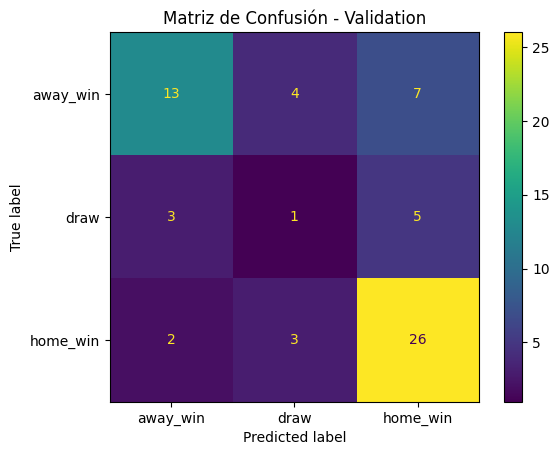

In [118]:
# Matriz de confusion Validation
cm = confusion_matrix(y_validation, val_pred)

print("\nMATRIZ DE CONFUSIÓN - VALIDATION\n")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["away_win", "draw", "home_win"]
)
disp.plot()
plt.title("Matriz de Confusión - Validation")
plt.show()

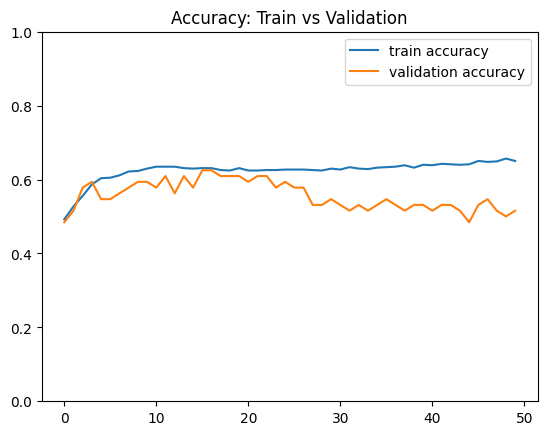

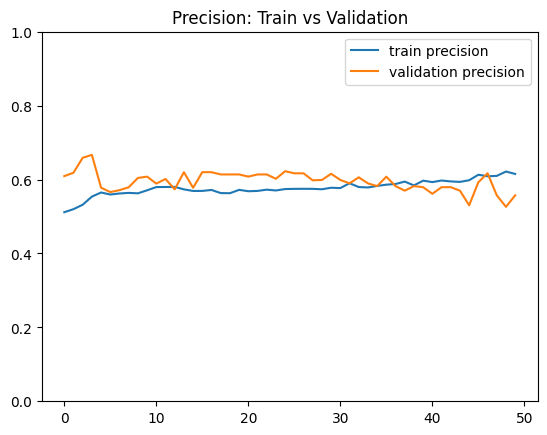

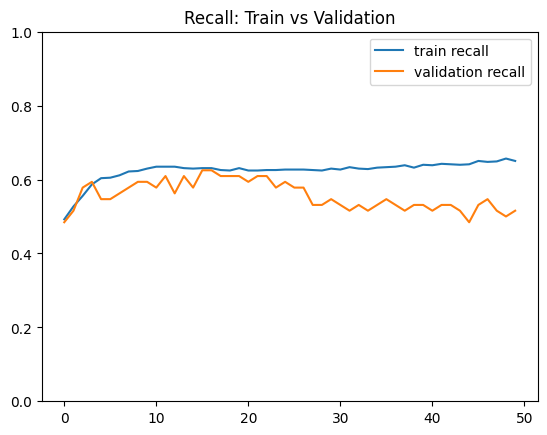

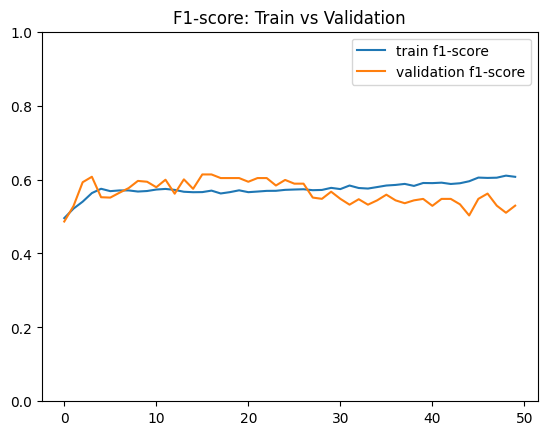

In [119]:
# Graficas Train vs Validation
plt.plot(metrics_callback.train_accuracy, label="train accuracy")
plt.plot(metrics_callback.val_accuracy, label="validation accuracy")
plt.ylim(0, 1)
plt.title("Accuracy: Train vs Validation")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_precision, label="train precision")
plt.plot(metrics_callback.val_precision, label="validation precision")
plt.ylim(0, 1)
plt.title("Precision: Train vs Validation")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_recall, label="train recall")
plt.plot(metrics_callback.val_recall, label="validation recall")
plt.ylim(0, 1)
plt.title("Recall: Train vs Validation")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_f1, label="train f1-score")
plt.plot(metrics_callback.val_f1, label="validation f1-score")
plt.ylim(0, 1)
plt.title("F1-score: Train vs Validation")
plt.legend()
plt.show()

In [120]:
# Probar modelo con Test
test_df = pd.read_csv("test.csv")

X_test = test_df[feature_columns]
y_test = test_df["result_label"]

X_test = scaler.transform(X_test)

test_pred_prob = best_model.predict(X_test)
test_pred = np.argmax(test_pred_prob, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [121]:
# Comparar
train_metrics = get_metrics(y_train, train_pred)
validation_metrics = get_metrics(y_validation, val_pred)
test_metrics = get_metrics(y_test, test_pred)

comparison_df = pd.DataFrame({
    "Train": train_metrics,
    "Validation": validation_metrics,
    "Test": test_metrics
})

print("\nCOMPARACIÓN TRAIN VS VALIDATION VS TEST\n")
print(comparison_df)


COMPARACIÓN TRAIN VS VALIDATION VS TEST

              Train  Validation      Test
Accuracy   0.630829    0.625000  0.523438
Precision  0.569174    0.619826  0.501101
Recall     0.630829    0.625000  0.523438
F1-score   0.565944    0.613723  0.507413


In [122]:
print("\nREPORTE POR CLASE - TEST\n")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["away_win", "draw", "home_win"],
        zero_division=0
    )
)


REPORTE POR CLASE - TEST

              precision    recall  f1-score   support

    away_win       0.52      0.44      0.48        50
        draw       0.14      0.11      0.12        19
    home_win       0.60      0.73      0.66        59

    accuracy                           0.52       128
   macro avg       0.42      0.42      0.42       128
weighted avg       0.50      0.52      0.51       128




MATRIZ DE CONFUSIÓN - TEST

[[22  9 19]
 [ 7  2 10]
 [13  3 43]]


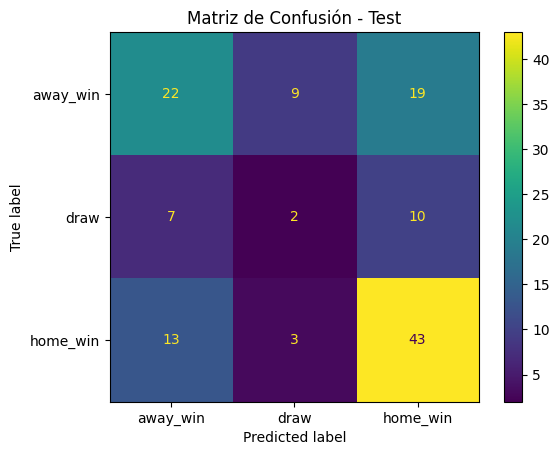

In [123]:
# Matriz confusion para test
cm_test = confusion_matrix(y_test, test_pred)

print("\nMATRIZ DE CONFUSIÓN - TEST\n")
print(cm_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["away_win", "draw", "home_win"]
)

disp.plot()
plt.title("Matriz de Confusión - Test")
plt.show()

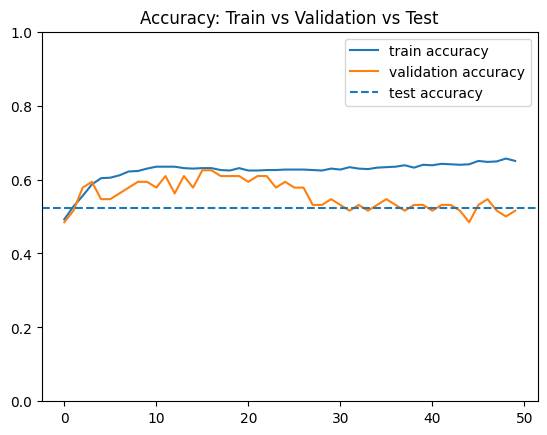

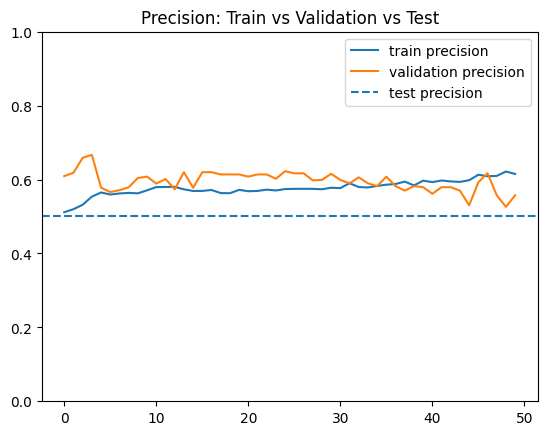

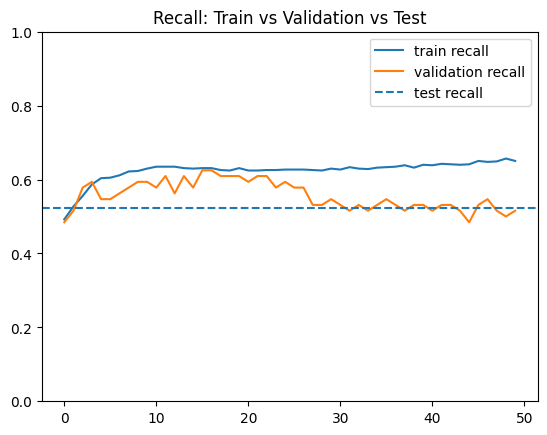

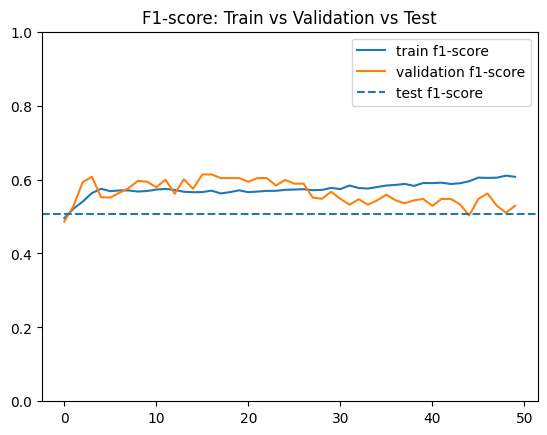

In [124]:
# Graficas
plt.plot(metrics_callback.train_accuracy, label="train accuracy")
plt.plot(metrics_callback.val_accuracy, label="validation accuracy")
plt.ylim(0, 1)
plt.axhline(y=test_metrics["Accuracy"], linestyle="--", label="test accuracy")
plt.title("Accuracy: Train vs Validation vs Test")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_precision, label="train precision")
plt.plot(metrics_callback.val_precision, label="validation precision")
plt.ylim(0, 1)
plt.axhline(y=test_metrics["Precision"], linestyle="--", label="test precision")
plt.title("Precision: Train vs Validation vs Test")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_recall, label="train recall")
plt.plot(metrics_callback.val_recall, label="validation recall")
plt.ylim(0, 1)
plt.axhline(y=test_metrics["Recall"], linestyle="--", label="test recall")
plt.title("Recall: Train vs Validation vs Test")
plt.legend()
plt.show()

plt.plot(metrics_callback.train_f1, label="train f1-score")
plt.plot(metrics_callback.val_f1, label="validation f1-score")
plt.ylim(0, 1)
plt.axhline(y=test_metrics["F1-score"], linestyle="--", label="test f1-score")
plt.title("F1-score: Train vs Validation vs Test")
plt.legend()
plt.show()